# 04. 모델 학습 (Model Training)

## 목적
**Masked Set Transformer** 모델 구현 및 학습

## 핵심 아키텍처
- Positional Encoding **제거** (재료는 순서 무관한 Set)
- 256차원 임베딩 (기존 64차원 → 256차원)
- 6 Layer, 8 Head Transformer
- Dynamic Masking (20%~80%)

## 학습 전략
- AdamW + Cosine Annealing Warm Restarts
- Mixed Precision (AMP)
- Gradient Clipping
- Early Stopping

## 입력
- `data/processed/recipe_v3/tokenizer.json`
- `data/processed/recipe_v3/dataset_info.pt`

## 출력
- `pred/models/masked_set_transformer_v1.pt`

In [2]:
# [1단계] Colab 환경 설정 및 Drive 마운트
import sys
import os

# Colab 환경 감지
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # 프로젝트 루트 설정 (본인의 Drive 경로에 맞게 수정)
    PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone'
    os.chdir(PROJECT_ROOT)
    sys.path.insert(0, f'{PROJECT_ROOT}/notebooks')

    # 한글 폰트 설치
    print("🔤 한글 폰트 설치 중...")
    import subprocess
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], capture_output=True)

    print(f"✅ Colab 환경 감지")
    print(f"📁 프로젝트 루트: {PROJECT_ROOT}")
else:
    from pathlib import Path
    PROJECT_ROOT = Path().resolve().parent
    sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

    print("💻 로컬 환경에서 실행 중")
    print(f"📁 프로젝트 루트: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔤 한글 폰트 설치 중...
✅ Colab 환경 감지
📁 프로젝트 루트: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone


In [3]:
# [2단계] 라이브러리 임포트
import gc
import json
import random
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Colab에서는 문자열을 Path로 변환
if IN_COLAB:
    PROJECT_ROOT = Path(PROJECT_ROOT)

# Gap Filling 유틸리티 임포트
from utils.gap_filling import (
    IngredientTokenizer,
    DynamicMaskingDataset,
    MaskedSetTransformer,
    Trainer,
    collate_fn
)

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

프로젝트 루트: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone
PyTorch 버전: 2.9.0+cu126
CUDA 사용 가능: True
GPU: NVIDIA L4
GPU 메모리: 22.2 GB


In [4]:
# 경로 설정 (Colab/로컬 자동 감지)
if IN_COLAB:
    from pathlib import Path
    PROJECT_ROOT = Path(PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'recipe_v3'
MODEL_DIR = PROJECT_ROOT / 'pred' / 'models'
LOG_DIR = PROJECT_ROOT / 'notebooks' / 'logs'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f"데이터 디렉토리: {DATA_DIR}")
print(f"모델 디렉토리: {MODEL_DIR}")

데이터 디렉토리: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3
모델 디렉토리: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/pred/models


In [5]:
# 디바이스 설정
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"학습 디바이스: {DEVICE}")

학습 디바이스: cuda


## 1. 데이터 로드

In [6]:
# 토크나이저 로드
tokenizer = IngredientTokenizer.load(str(DATA_DIR / 'tokenizer.json'))
print(f"토크나이저 로드: vocab_size={tokenizer.vocab_size}")

# 데이터셋 정보 로드
dataset_info = torch.load(DATA_DIR / 'dataset_info.pt')
train_recipes = dataset_info['train_recipes']
val_recipes = dataset_info['val_recipes']
MAX_LEN = dataset_info['max_len']

print(f"학습 레시피: {len(train_recipes):,}")
print(f"검증 레시피: {len(val_recipes):,}")
print(f"최대 길이: {MAX_LEN}")

토크나이저 로드: vocab_size=12089
학습 레시피: 181,937
검증 레시피: 20,216
최대 길이: 32


## 2. 하이퍼파라미터 설정

In [7]:
# 모델 설정
MODEL_CONFIG = {
    'vocab_size': tokenizer.vocab_size,
    'd_model': 256,       # 임베딩 차원 (기존 64 → 256)
    'n_heads': 8,         # 어텐션 헤드 수
    'n_layers': 6,        # 트랜스포머 레이어 수
    'd_ff': 1024,         # FFN 차원
    'dropout': 0.1,       # 드롭아웃
    'pad_id': tokenizer.PAD_ID
}

# 학습 설정
# NOTE: 배치 사이즈 256은 Colab T4/A100에서 최적
#       메모리 부족 시 128로 줄이고 gradient_accumulation 사용 권장
TRAINING_CONFIG = {
    'batch_size': 256,     # 64 → 256 (GPU 활용 극대화)
    'learning_rate': 2e-4, # 배치 증가에 맞춰 학습률도 2배 증가
    'weight_decay': 0.01,
    'n_epochs': 50,
    'patience': 7,         # 배치가 커지면 수렴 느려질 수 있어 patience 증가
    'grad_clip': 1.0,
    'warmup_steps': 500,   # 배치 증가 → 스텝 감소 → warmup도 줄임
    'mask_ratio_range': (0.2, 0.8),
}

print("=== 모델 설정 ===")
for k, v in MODEL_CONFIG.items():
    print(f"  {k}: {v}")

print("\n=== 학습 설정 ===")
for k, v in TRAINING_CONFIG.items():
    print(f"  {k}: {v}")
print("\n⚡ 배치 사이즈 256 설정 (GPU 메모리 16GB+ 권장)")

=== 모델 설정 ===
  vocab_size: 12089
  d_model: 256
  n_heads: 8
  n_layers: 6
  d_ff: 1024
  dropout: 0.1
  pad_id: 0

=== 학습 설정 ===
  batch_size: 256
  learning_rate: 0.0002
  weight_decay: 0.01
  n_epochs: 50
  patience: 7
  grad_clip: 1.0
  warmup_steps: 500
  mask_ratio_range: (0.2, 0.8)

⚡ 배치 사이즈 256 설정 (GPU 메모리 16GB+ 권장)


## 3. 데이터셋 및 DataLoader 생성

In [8]:
# 학습 데이터셋
train_dataset = DynamicMaskingDataset(
    recipes=train_recipes,
    tokenizer=tokenizer,
    max_len=MAX_LEN,
    mask_ratio_range=TRAINING_CONFIG['mask_ratio_range'],
    shuffle_ingredients=True,
    bert_style_masking=True
)

# 검증 데이터셋
val_dataset = DynamicMaskingDataset(
    recipes=val_recipes,
    tokenizer=tokenizer,
    max_len=MAX_LEN,
    mask_ratio_range=(0.3, 0.5),
    shuffle_ingredients=False,
    bert_style_masking=False
)

print(f"학습 데이터셋: {len(train_dataset):,}")
print(f"검증 데이터셋: {len(val_dataset):,}")

학습 데이터셋: 181,937
검증 데이터셋: 20,216


In [9]:
# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAINING_CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,  # Windows 호환
    collate_fn=collate_fn,
    pin_memory=True if DEVICE == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=TRAINING_CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
    pin_memory=True if DEVICE == 'cuda' else False
)

print(f"학습 배치 수: {len(train_loader):,}")
print(f"검증 배치 수: {len(val_loader):,}")

학습 배치 수: 711
검증 배치 수: 79


## 4. 모델 초기화

In [10]:
# 모델 생성
model = MaskedSetTransformer(**MODEL_CONFIG)

print(f"\n=== 모델 정보 ===")
print(f"총 파라미터: {model.num_parameters:,}")
print(f"모델 크기: {model.num_parameters * 4 / 1024 / 1024:.1f} MB (float32)")


=== 모델 정보 ===
총 파라미터: 7,912,249
모델 크기: 30.2 MB (float32)


In [11]:
# 모델 구조 확인
print(model)

MaskedSetTransformer(
  (embedding): Embedding(12089, 256, padding_idx=0)
  (embed_dropout): Dropout(p=0.1, inplace=False)
  (encoder): SetTransformerEncoder(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (mlm_head): Sequential(


In [12]:
# GPU 메모리 사용량 테스트
if DEVICE == 'cuda':
    model = model.to(DEVICE)

    # 더미 배치로 메모리 테스트
    dummy_batch = next(iter(train_loader))
    dummy_input = dummy_batch['input_ids'].to(DEVICE)
    dummy_mask = dummy_batch['attention_mask'].to(DEVICE)
    dummy_labels = dummy_batch['labels'].to(DEVICE)

    with torch.no_grad():
        _ = model(dummy_input, dummy_mask, dummy_labels)

    print(f"\nGPU 메모리 사용량: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"GPU 메모리 캐시: {torch.cuda.memory_reserved() / 1024**2:.1f} MB")

    del dummy_input, dummy_mask, dummy_labels
    torch.cuda.empty_cache()


GPU 메모리 사용량: 425.7 MB
GPU 메모리 캐시: 940.0 MB


## 5. 트레이너 설정 및 학습

In [13]:
# 체크포인트 디렉토리
checkpoint_dir = str(LOG_DIR / f'run_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"체크포인트 디렉토리: {checkpoint_dir}")

체크포인트 디렉토리: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/notebooks/logs/run_20251219_185830


In [14]:
# 트레이너 초기화
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    learning_rate=TRAINING_CONFIG['learning_rate'],
    weight_decay=TRAINING_CONFIG['weight_decay'],
    warmup_steps=TRAINING_CONFIG['warmup_steps'],
    grad_clip=TRAINING_CONFIG['grad_clip'],
    use_amp=True,  # Mixed Precision
    device=DEVICE,
    patience=TRAINING_CONFIG['patience'],
    checkpoint_dir=checkpoint_dir,
    scheduler_type='cosine'
)

In [15]:
# 학습 시작
print("\n" + "="*50)
print("학습 시작")
print("="*50)

history = trainer.train(n_epochs=TRAINING_CONFIG['n_epochs'])


학습 시작


## 6. 학습 결과 시각화

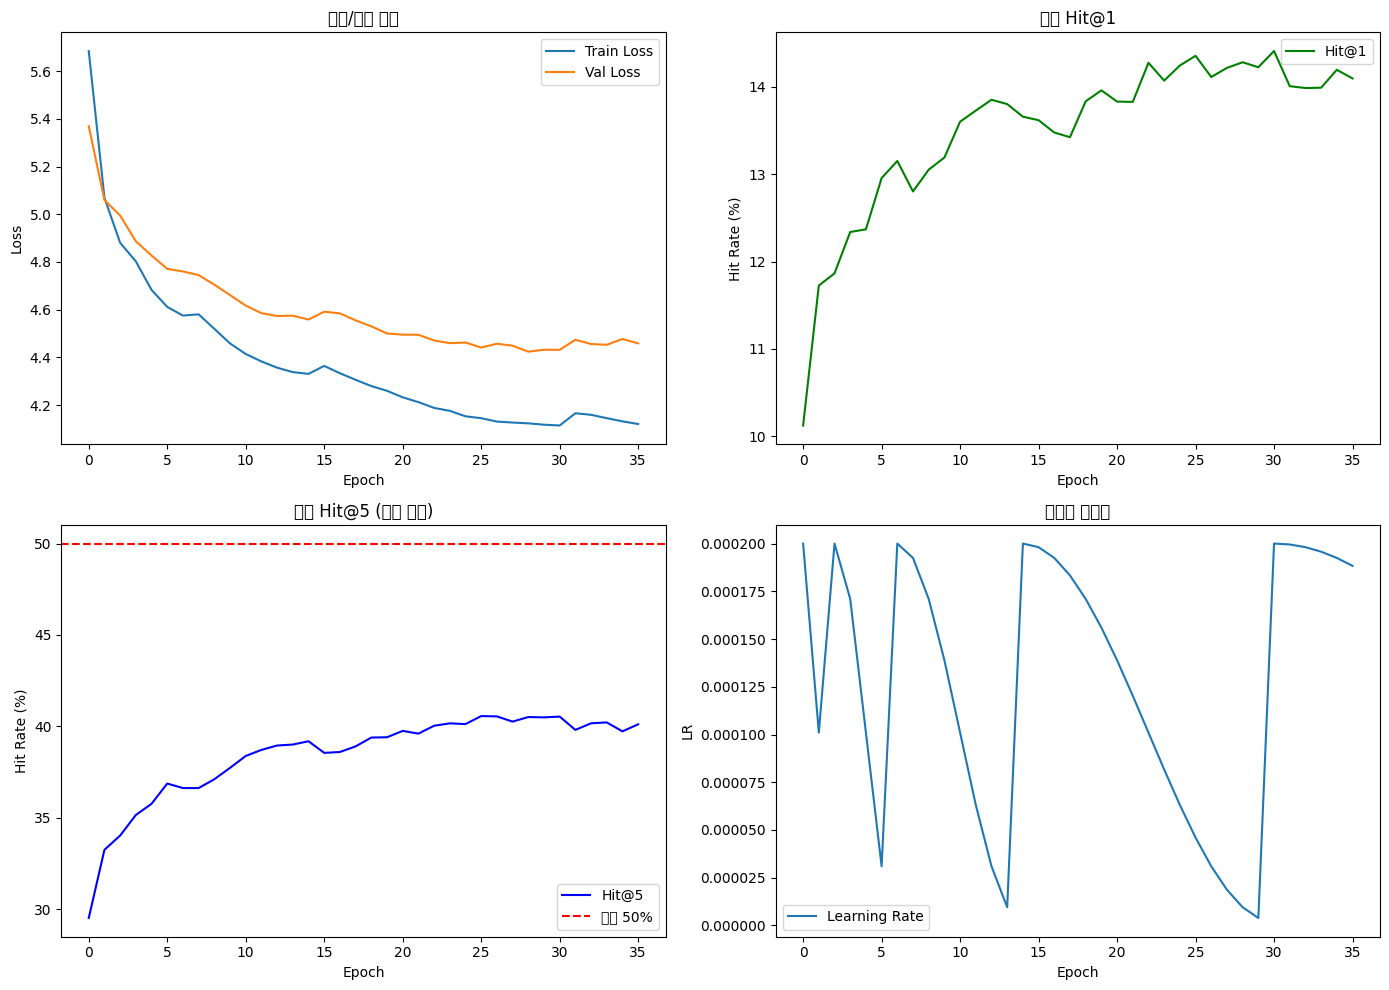

In [16]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Colab/로컬 자동 감지)
if IN_COLAB:
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 손실 곡선
axes[0, 0].plot(history['train_loss'], label='Train Loss')
if history['val_loss']:
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('학습/검증 손실')
axes[0, 0].legend()

# Hit@1 곡선
if history['val_hit_at_1']:
    axes[0, 1].plot(history['val_hit_at_1'], label='Hit@1', color='green')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Hit Rate (%)')
    axes[0, 1].set_title('검증 Hit@1')
    axes[0, 1].legend()

# Hit@5 곡선
if history['val_hit_at_5']:
    axes[1, 0].plot(history['val_hit_at_5'], label='Hit@5', color='blue')
    axes[1, 0].axhline(y=50, color='red', linestyle='--', label='목표 50%')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Hit Rate (%)')
    axes[1, 0].set_title('검증 Hit@5 (핵심 지표)')
    axes[1, 0].legend()

# 학습률 곡선
axes[1, 1].plot(history['learning_rate'], label='Learning Rate')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('LR')
axes[1, 1].set_title('학습률 스케줄')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f"{checkpoint_dir}/training_curves.png", dpi=150)
plt.show()

## 7. 최고 모델 로드 및 저장

In [17]:
# 최고 성능 모델 로드
best_checkpoint = os.path.join(checkpoint_dir, 'best_model.pt')
if os.path.exists(best_checkpoint):
    trainer.load_checkpoint(best_checkpoint)
    print("최고 성능 모델 로드 완료")

최고 성능 모델 로드 완료


In [18]:
# 최종 모델 저장
model_path = MODEL_DIR / 'masked_set_transformer_v1.pt'
model.save_pretrained(str(model_path))
print(f"모델 저장: {model_path}")

모델 저장: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/pred/models/masked_set_transformer_v1.pt


In [19]:
# 학습 설정 저장
training_info = {
    'model_config': MODEL_CONFIG,
    'training_config': TRAINING_CONFIG,
    'best_epoch': trainer.best_epoch,
    'best_val_loss': trainer.best_val_loss,
    'final_metrics': {
        'train_loss': history['train_loss'][-1] if history['train_loss'] else None,
        'val_loss': history['val_loss'][-1] if history['val_loss'] else None,
        'val_hit_at_1': history['val_hit_at_1'][-1] if history['val_hit_at_1'] else None,
        'val_hit_at_5': history['val_hit_at_5'][-1] if history['val_hit_at_5'] else None,
    },
    'timestamp': datetime.now().isoformat()
}

with open(f"{checkpoint_dir}/training_info.json", 'w', encoding='utf-8') as f:
    json.dump(training_info, f, ensure_ascii=False, indent=2)

print(f"학습 정보 저장: {checkpoint_dir}/training_info.json")

학습 정보 저장: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/notebooks/logs/run_20251219_185830/training_info.json


## 8. 간단한 추론 테스트

In [20]:
# 추론 테스트
model.eval()

test_ingredients = ['돼지고기', '양파', '마늘']
print(f"\n입력 재료: {test_ingredients}")

# 인코딩
input_ids = [tokenizer.CLS_ID]
for ing in test_ingredients:
    input_ids.append(tokenizer.get_token_id(ing))
input_ids.append(tokenizer.MASK_ID)  # 예측할 위치
input_ids.append(tokenizer.SEP_ID)

# 패딩
pad_len = MAX_LEN - len(input_ids)
attention_mask = [1] * len(input_ids) + [0] * pad_len
input_ids = input_ids + [tokenizer.PAD_ID] * pad_len

# 텐서 변환
input_tensor = torch.tensor([input_ids], dtype=torch.long, device=DEVICE)
mask_tensor = torch.tensor([attention_mask], dtype=torch.long, device=DEVICE)

# 예측
with torch.no_grad():
    output = model(input_tensor, mask_tensor)
    logits = output['logits'][0, len(test_ingredients) + 1]  # MASK 위치

    # 입력 재료 및 특수 토큰 제외
    for ing in test_ingredients:
        logits[tokenizer.get_token_id(ing)] = float('-inf')
    for special_id in [tokenizer.PAD_ID, tokenizer.MASK_ID, tokenizer.UNK_ID,
                       tokenizer.CLS_ID, tokenizer.SEP_ID]:
        logits[special_id] = float('-inf')

    # Top-10 예측
    top_k = 10
    probs = torch.softmax(logits, dim=-1)
    top_probs, top_ids = torch.topk(probs, k=top_k)

print(f"\n추천 재료 (Top-{top_k}):")
for i, (idx, prob) in enumerate(zip(top_ids, top_probs), 1):
    ingredient = tokenizer.get_token(idx.item())
    print(f"  {i}. {ingredient} ({prob.item()*100:.1f}%)")


입력 재료: ['돼지고기', '양파', '마늘']

추천 재료 (Top-10):
  1. 파 (16.3%)
  2. 후추 (7.3%)
  3. 된장 (4.2%)
  4. 고추가루 (3.6%)
  5. 고추 (3.5%)
  6. 버섯 (3.5%)
  7. 배추 (2.9%)
  8. 간장 (2.3%)
  9. 감자 (2.3%)
  10. 당근 (2.3%)


In [21]:
# 최종 요약
print("\n" + "="*50)
print("모델 학습 완료")
print("="*50)
print(f"\n모델:")
print(f"  - 아키텍처: Masked Set Transformer")
print(f"  - 파라미터: {model.num_parameters:,}")
print(f"  - 임베딩 차원: {MODEL_CONFIG['d_model']}")
print(f"\n성능 (마지막 에폭):")
if history['val_hit_at_5']:
    print(f"  - Val Hit@5: {history['val_hit_at_5'][-1]:.2f}%")
print(f"\n저장된 파일:")
print(f"  - {model_path}")
print(f"  - {checkpoint_dir}/training_curves.png")
print(f"  - {checkpoint_dir}/training_info.json")


모델 학습 완료

모델:
  - 아키텍처: Masked Set Transformer
  - 파라미터: 7,912,249
  - 임베딩 차원: 256

성능 (마지막 에폭):
  - Val Hit@5: 40.11%

저장된 파일:
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/pred/models/masked_set_transformer_v1.pt
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/notebooks/logs/run_20251219_185830/training_curves.png
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/notebooks/logs/run_20251219_185830/training_info.json


In [22]:
# 메모리 정리
del train_dataset, val_dataset, train_loader, val_loader
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
gc.collect()
print("메모리 정리 완료")

메모리 정리 완료
